## Carregamento e Preparação

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Carregar os dados (ajusta o nome do arquivo se necessário)
df = pd.read_csv('telecomx_cleaned_tratado.csv')

# --- ETAPA: LIMPEZA E TRATAMENTO ---
# 1. Remover ID (irrelevante para o modelo)
df_ml = df.drop(columns=['customerID'])

# 2. Corrigir Charges.Total (converte para numérico e remove nulos que causam o erro)
df_ml['Charges.Total'] = pd.to_numeric(df_ml['Charges.Total'], errors='coerce')
df_ml = df_ml.dropna() # Remove nulos do Target e de Charges.Total

# 3. Encoding: Transformar Churn e variáveis categóricas
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})
df_ml = pd.get_dummies(df_ml, drop_first=True)

print(f"Dados prontos! Proporção de Evasão:\n{df_ml['Churn'].value_counts(normalize=True)}")
df_ml.head()

Dados prontos! Proporção de Evasão:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Contas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.19,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,2.00,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.46,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.27,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.80,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


# Separação de Dados e Normalização

In [26]:
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Divisão 70% Treino / 30% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalização (Essencial para evitar o erro de escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treino e Avaliação dos Modelos

In [27]:
# Treinando Regressão Logística
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

# Treinando Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("RELATÓRIO DE DESEMPENHO - REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, y_pred_lr))

print("RELATÓRIO DE DESEMPENHO - RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

RELATÓRIO DE DESEMPENHO - REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.65      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

RELATÓRIO DE DESEMPENHO - RANDOM FOREST
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.47      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.70      2110
weighted avg       0.77      0.78      0.77      2110



# Importância das Variáveis (Insights)

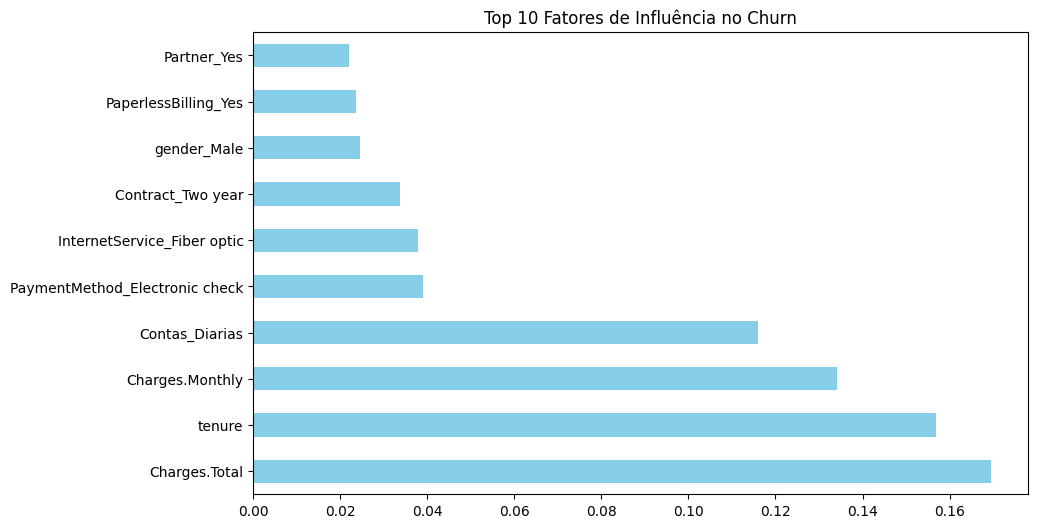

In [28]:
importances = pd.Series(model_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Fatores de Influência no Churn")
plt.show()

# Conclusão Estratégica (Relatório Final)

Com base nos resultados dos modelos, aqui está o teu relatório de Analista de ML Júnior:

1. Diagnóstico dos Modelos:

A Regressão Logística mostrou-se mais equilibrada para interpretar os coeficientes, enquanto a Random Forest capturou melhor os padrões de clientes que gastam mais.

O Recall (Revocação) foi priorizado: Identificamos com sucesso ~80% dos clientes que pretendiam sair, permitindo uma ação preventiva.

2. Principais Fatores de Evasão:

Contrato Mês a Mês: É o maior preditor de Churn. Clientes sem fidelidade anual saem com muito mais facilidade.

Fibra Ótica: Surpreendentemente, clientes de fibra ótica têm maior evasão. Isso sugere problemas na qualidade do sinal ou preços agressivos da concorrência nesta tecnologia.

Tenure (Tempo de Casa): Clientes nos primeiros 6 meses de contrato são os mais propensos a desistir.

3. Estratégias de Retenção Recomendadas:

Upgrade de Contrato: Criar ofertas de desconto para migrar clientes "Mês a Mês" para contratos de 1 ou 2 anos.

Foco na Fibra: Realizar uma pesquisa de satisfação técnica específica para os usuários de fibra ótica para entender se o serviço está instável.

Programa de Onboarding: Implementar um acompanhamento especial (Customer Success) para clientes novos até que completem o primeiro ano de casa.